# Generate distribution plots for the features used to detect poor quality segmentations

This code is derived from the `cellpainting_predicts_cardiac_fibrosis` repository.

In [1]:
import pathlib

import numpy as np
import pandas as pd
from plotnine import *
from plotnine.options import set_option

from cosmicqc import find_outliers

In [2]:
# Directory with data
data_dir = pathlib.Path(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/converted_profiles/"
)

# Directory to save cleaned data
figure_dir = pathlib.Path("./figures")
figure_dir.mkdir(exist_ok=True)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

In [3]:
# Load in converted plate data
plate_df = pd.read_parquet(f"{data_dir}/localhost230405150001_converted.parquet")

print(plate_df.shape)
plate_df.head()

(25859, 2016)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_Hoechst_3_02_256,Nuclei_Texture_Variance_Hoechst_3_03_256,Nuclei_Texture_Variance_Mitochondria_3_00_256,Nuclei_Texture_Variance_Mitochondria_3_01_256,Nuclei_Texture_Variance_Mitochondria_3_02_256,Nuclei_Texture_Variance_Mitochondria_3_03_256,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256
0,221.046761,137.115493,246.602800,109.285755,40,1,localhost230405150001,f00,B02,1,...,2.950736,2.938125,0.529422,0.478064,0.489459,0.475133,2.703146,2.664110,2.650578,2.664691
1,690.596142,183.067828,716.170091,177.132195,40,1,localhost230405150001,f00,B02,2,...,2.619951,2.551946,46.883295,50.496897,42.311975,39.973584,4.376776,4.567953,4.220630,4.058367
2,626.561490,206.923698,623.943740,199.906440,40,1,localhost230405150001,f00,B02,3,...,1.441226,1.430094,0.970588,0.952145,0.950279,0.908622,2.568485,2.578927,2.556851,2.541355
3,559.448583,220.688160,528.646623,196.955552,40,1,localhost230405150001,f00,B02,4,...,2.593248,2.660096,2.511639,2.456358,2.509622,2.547159,3.866945,4.011720,4.004412,3.866034
4,909.019946,247.694340,897.965996,253.621836,40,1,localhost230405150001,f00,B02,5,...,1.625771,1.629242,5.823674,6.553608,6.620230,5.453092,2.029099,2.044566,2.038007,2.058557


In [4]:
# Set outlier threshold that maximizes removing most technical outliers
outlier_threshold = 2

# find large nuclei and high intensity
feature_thresholds = {
    "Nuclei_AreaShape_Area": outlier_threshold,
    "Nuclei_Intensity_IntegratedIntensity_Hoechst": outlier_threshold,
}

large_nuclei_high_int_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

print(large_nuclei_high_int_outliers.shape)
pd.DataFrame(large_nuclei_high_int_outliers.head())

Number of outliers: 444 (1.72%)
Outliers Range:
Nuclei_AreaShape_Area Min: 2615.0
Nuclei_AreaShape_Area Max: 7604.0
Nuclei_Intensity_IntegratedIntensity_Hoechst Min: 150.04394634626806
Nuclei_Intensity_IntegratedIntensity_Hoechst Max: 836.8383014723659
(444, 7)


,Nuclei_AreaShape_Area,Nuclei_Intensity_IntegratedIntensity_Hoechst,Image_Metadata_Plate,Image_Metadata_Well,Image_Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y
37,3990.0,154.616541,localhost230405150001,B02,f00,177.249624,983.235589
107,4179.0,191.951339,localhost230405150001,B02,f03,51.247428,222.126346
154,6340.0,258.128116,localhost230405150001,B02,f04,621.836751,421.906940
234,2975.0,158.979675,localhost230405150001,B02,f07,41.622185,178.953950
258,4291.0,266.441139,localhost230405150001,B02,f07,619.858774,616.496854


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/distribution_nuclei_outliers.png


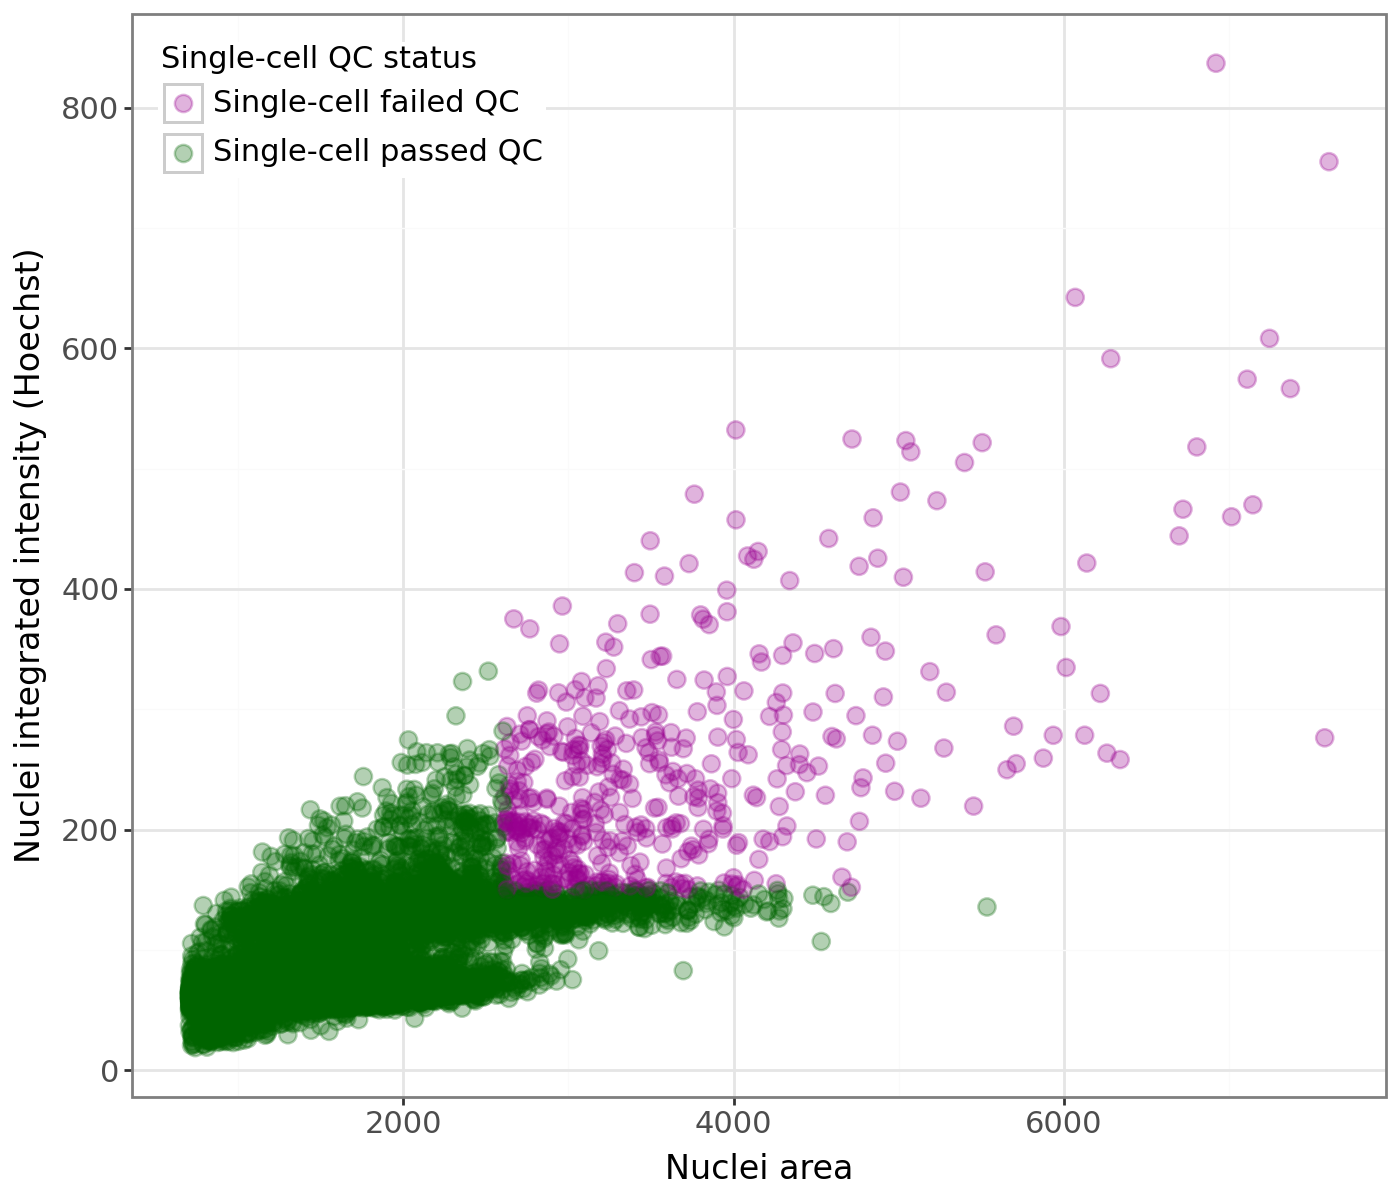

In [5]:
# Set the default value to 'Single-cell passed QC'
plate_df["Outlier_Status"] = "Single-cell passed QC"

# Update Outlier_Status based on outliers index
plate_df.loc[
    plate_df.index.isin(large_nuclei_high_int_outliers.index), "Outlier_Status"
] = "Single-cell failed QC"

# Define colors
color_dict = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Set the figure size
height = 6
width = 7
set_option("figure_size", (width, height))

# Create the plot
p = (
    ggplot(
        plate_df,
        aes(
            x="Nuclei_AreaShape_Area",
            y="Nuclei_Intensity_IntegratedIntensity_Hoechst",
            color="Outlier_Status",
        ),
    )
    + geom_point(alpha=0.3, size=3)
    + scale_color_manual(values=color_dict)
    + labs(
        x="Nuclei area",
        y="Nuclei integrated intensity (Hoechst)",
        color="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.03, 0.97),
        legend_direction="vertical",
        legend_text=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=11),
    )
)

# Save figure
p.save(
    f"{figure_dir}/distribution_nuclei_outliers.png",
    dpi=500,
    width=width,
    height=height,
)

# Show plot
p.show()

In [6]:
# Set threshold to detect outliers (abnormally small cells)
feature_thresholds = {
    "Cells_AreaShape_Area": -0.9,
}


small_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

print(small_cells_outliers.shape)
pd.DataFrame(small_cells_outliers).sort_values(
    by="Cells_AreaShape_Area", ascending=False
).head()

Number of outliers: 4553 (17.61%)
Outliers Range:
Cells_AreaShape_Area Min: 708.0
Cells_AreaShape_Area Max: 2866.0
(4553, 6)


,Cells_AreaShape_Area,Image_Metadata_Plate,Image_Metadata_Well,Image_Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y
6160,2866.0,localhost230405150001,C04,f03,442.290237,793.576517
25164,2865.0,localhost230405150001,G10,f00,101.571025,469.293993
79,2865.0,localhost230405150001,B02,f02,678.568528,405.227157
18866,2864.0,localhost230405150001,E10,f06,262.386059,854.742627
20354,2864.0,localhost230405150001,G04,f00,743.068685,463.603027


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/distribution_cells_outliers.png


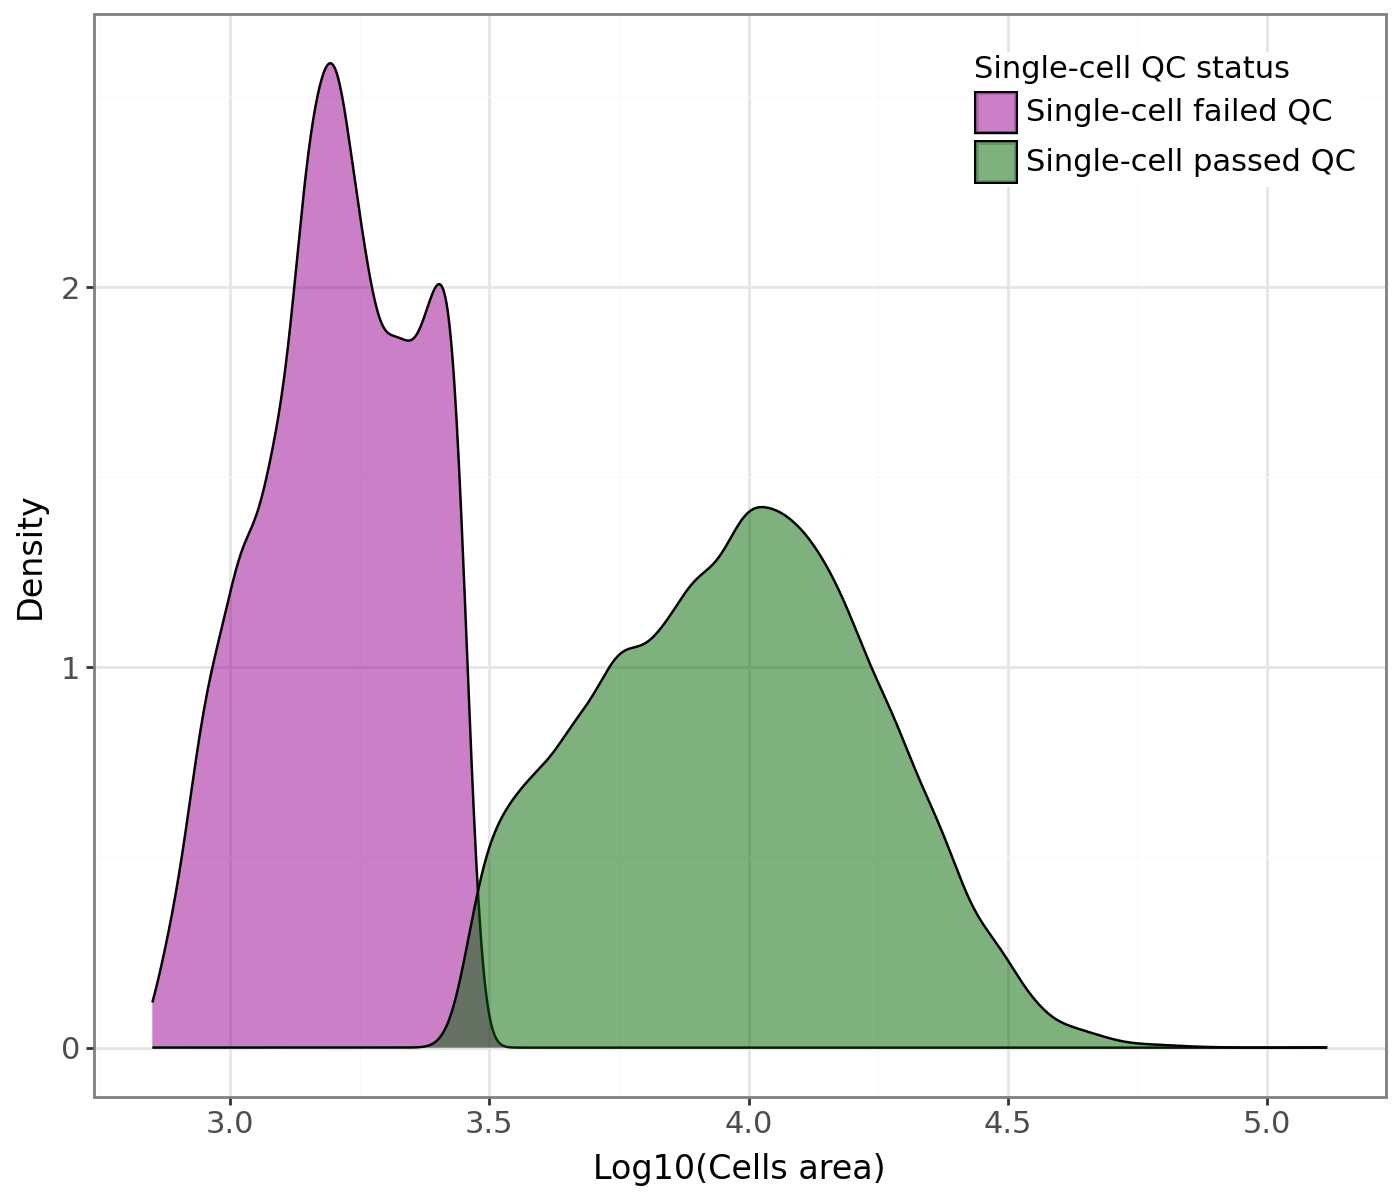

In [7]:
# Create Outlier_Status column
plate_df["Outlier_Status"] = "Single-cell passed QC"
plate_df.loc[plate_df.index.isin(small_cells_outliers.index), "Outlier_Status"] = (
    "Single-cell failed QC"
)

# Take log10 of the cell area
plate_df["Log_Cells_Area"] = np.log10(plate_df["Cells_AreaShape_Area"])

# Define colors
fill_colors = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Create the density plot
p = (
    ggplot(plate_df, aes(x="Log_Cells_Area", fill="Outlier_Status"))
    + geom_density(alpha=0.5)
    + scale_fill_manual(values=fill_colors)
    + labs(x="Log10(Cells area)", y="Density", fill="Single-cell QC status")
    + theme_bw()
    + theme(
        legend_position=(0.97, 0.96),
        legend_text=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=11),
    )
)

# Save figure
p.save(
    f"{figure_dir}/distribution_cells_outliers.png", dpi=500, width=width, height=height
)

# Show plot
p.show()